In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt




In [10]:
# Loadng the data
df=pd.read_csv("country_wise_latest.csv")
df.head()


,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [11]:
#Handle missing data
print(df.isnull().sum())

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64


In [12]:
continents = df['WHO Region'].unique()  
continent_populations = {
    "Africa": 1_300_000_000,
    "Europe": 750_000_000,
    "Americas": 1_000_000_000,
    "Eastern Mediterranean": 700_000_000,
    "South-East Asia": 2_000_000_000,
    "Western Pacific": 1_900_000_000
}

In [13]:
def sir_equations(y, t, N, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I / N
    dIdt = beta * S * I / N - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

In [14]:
from scipy.integrate import odeint
def run_simulation(beta, gamma, days, N, I0, R0):
    S0 = N - I0 - R0
    y0 = [S0, I0, R0]
    sol = odeint(sir_equations, y0, days, args=(N, beta, gamma))
    return sol

In [15]:
def objective_function(params, days, y_active, N, I0, R0):
    beta, gamma = params
    prediction = run_simulation(beta, gamma, days, N, I0, R0)
    return np.sqrt(np.mean((prediction[:,1] - y_active)**2))

In [16]:
continent_populations = {
    "Africa": 1_300_000_000,
    "Europe": 750_000_000,
    "Americas": 1_000_000_000,
    "Eastern Mediterranean": 700_000_000,
    "South-East Asia": 2_000_000_000,
    "Western Pacific": 1_900_000_000
}

continents = df['WHO Region'].unique()

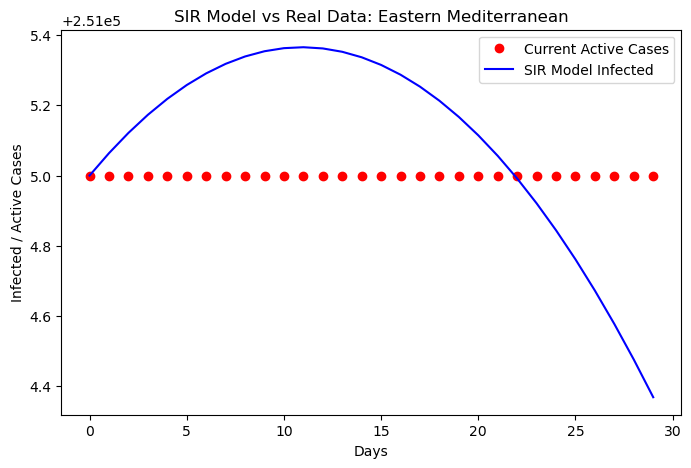

--- Eastern Mediterranean ---
Beta (Spread Rate): 0.0082
Gamma (Recovery Rate): 0.0082
Calculated R0: 1.00



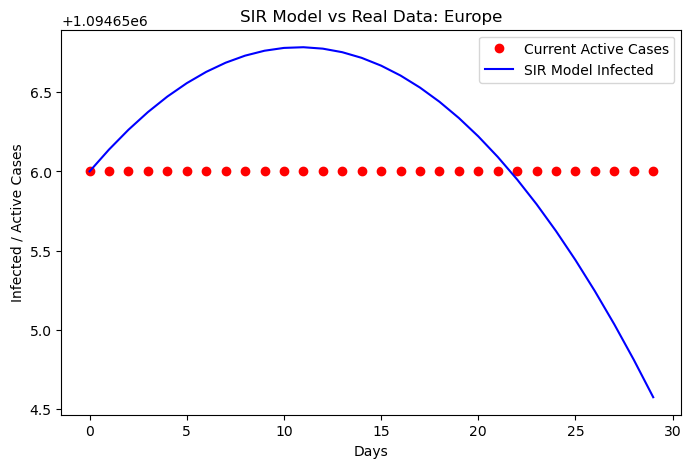

--- Eastern Mediterranean ---
Beta (Spread Rate): 0.0082
Gamma (Recovery Rate): 0.0082
Calculated R0: 1.00

--- Europe ---
Beta (Spread Rate): 0.0029
Gamma (Recovery Rate): 0.0029
Calculated R0: 1.00



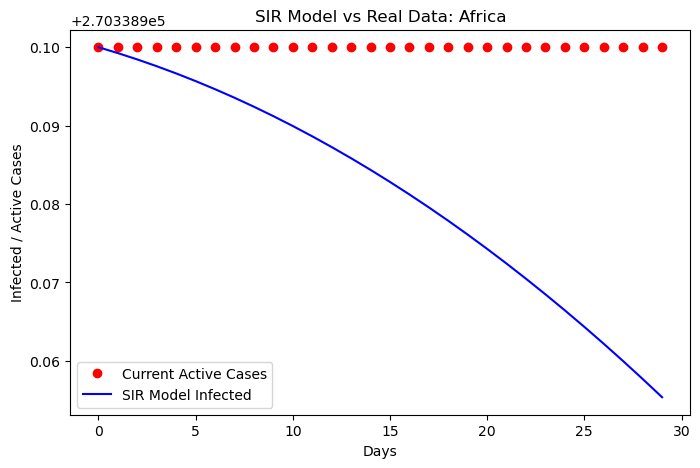

--- Eastern Mediterranean ---
Beta (Spread Rate): 0.0082
Gamma (Recovery Rate): 0.0082
Calculated R0: 1.00

--- Europe ---
Beta (Spread Rate): 0.0029
Gamma (Recovery Rate): 0.0029
Calculated R0: 1.00

--- Africa ---
Beta (Spread Rate): 0.0010
Gamma (Recovery Rate): 0.0010
Calculated R0: 1.00



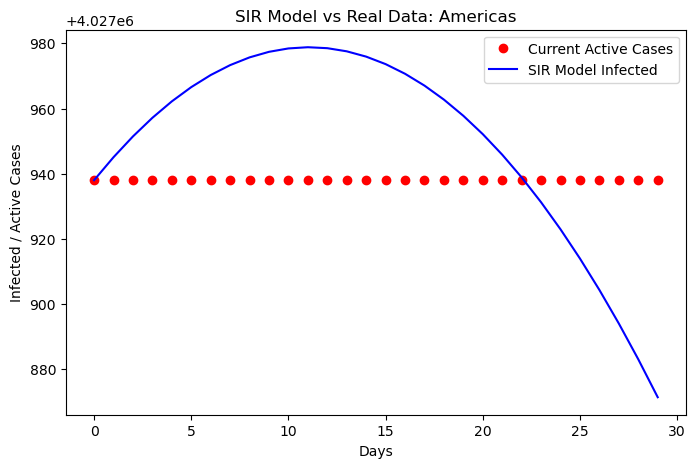

--- Eastern Mediterranean ---
Beta (Spread Rate): 0.0082
Gamma (Recovery Rate): 0.0082
Calculated R0: 1.00

--- Europe ---
Beta (Spread Rate): 0.0029
Gamma (Recovery Rate): 0.0029
Calculated R0: 1.00

--- Africa ---
Beta (Spread Rate): 0.0010
Gamma (Recovery Rate): 0.0010
Calculated R0: 1.00

--- Americas ---
Beta (Spread Rate): 0.0064
Gamma (Recovery Rate): 0.0064
Calculated R0: 1.01



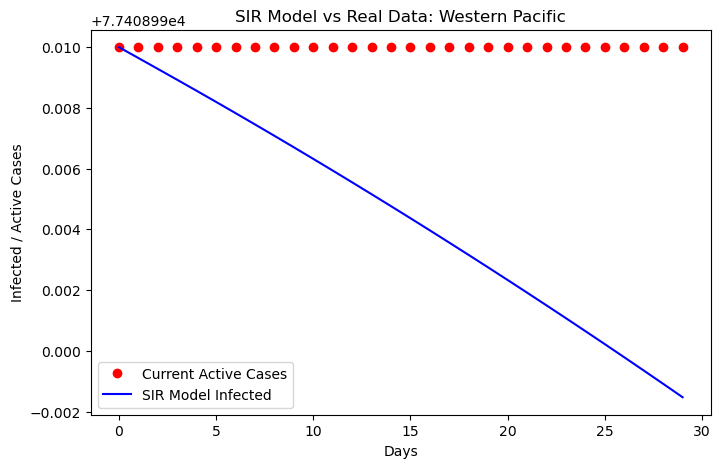

--- Eastern Mediterranean ---
Beta (Spread Rate): 0.0082
Gamma (Recovery Rate): 0.0082
Calculated R0: 1.00

--- Europe ---
Beta (Spread Rate): 0.0029
Gamma (Recovery Rate): 0.0029
Calculated R0: 1.00

--- Africa ---
Beta (Spread Rate): 0.0010
Gamma (Recovery Rate): 0.0010
Calculated R0: 1.00

--- Americas ---
Beta (Spread Rate): 0.0064
Gamma (Recovery Rate): 0.0064
Calculated R0: 1.01

--- Western Pacific ---
Beta (Spread Rate): 0.0010
Gamma (Recovery Rate): 0.0010
Calculated R0: 1.00



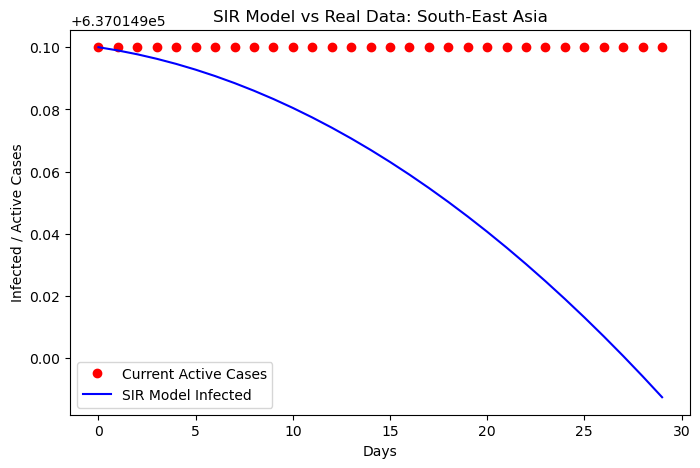

--- Eastern Mediterranean ---
Beta (Spread Rate): 0.0082
Gamma (Recovery Rate): 0.0082
Calculated R0: 1.00

--- Europe ---
Beta (Spread Rate): 0.0029
Gamma (Recovery Rate): 0.0029
Calculated R0: 1.00

--- Africa ---
Beta (Spread Rate): 0.0010
Gamma (Recovery Rate): 0.0010
Calculated R0: 1.00

--- Americas ---
Beta (Spread Rate): 0.0064
Gamma (Recovery Rate): 0.0064
Calculated R0: 1.01

--- Western Pacific ---
Beta (Spread Rate): 0.0010
Gamma (Recovery Rate): 0.0010
Calculated R0: 1.00

--- South-East Asia ---
Beta (Spread Rate): 0.0010
Gamma (Recovery Rate): 0.0010
Calculated R0: 1.00



In [23]:
from scipy.optimize import minimize
results = {}

for continent in continents:
   
    continent_data = df[df['WHO Region'] == continent]
    
    # Total current active and removed cases
    y_active = continent_data['Active'].sum()
    y_removed = (continent_data['Recovered'].sum() + continent_data['Deaths'].sum())
    
    # Simulation days 
    days = np.arange(30)
    
    # Population
    N = continent_populations.get(continent, 1_000_000_000)
    I0 = y_active
    R0 = y_removed
    
    
    initial_guess = [0.2, 0.1]
    
    # Optimize beta & gamma
    result = minimize(
        objective_function, 
        initial_guess, 
        args=(days, np.full(len(days), I0), N, I0, R0),
        bounds=[(0.001, 1), (0.001, 1)]
    )
    
    best_beta, best_gamma = result.x
    R0_value = best_beta / best_gamma
    
    # Save results
    results[continent] = {
        "beta": best_beta,
        "gamma": best_gamma,
        "R0": R0_value
    }
    
    # Simulate SIR with fitted parameters
    sol = run_simulation(best_beta, best_gamma, days, N, I0, R0)


    # Plotting
    plt.figure(figsize=(8,5))
    plt.plot(days, np.full(len(days), I0), 'ro', label="Current Active Cases")
    plt.plot(days, sol[:,1], 'b-', label="SIR Model Infected")
    plt.title(f"SIR Model vs Real Data: {continent}")
    plt.xlabel("Days")
    plt.ylabel("Infected / Active Cases")
    plt.legend()
    plt.show()

    for continent, res in results.items():
        print(f"--- {continent} ---")
        print(f"Beta (Spread Rate): {res['beta']:.4f}")
        print(f"Gamma (Recovery Rate): {res['gamma']:.4f}")
        print(f"Calculated R0: {res['R0']:.2f}\n")